<a href="https://colab.research.google.com/github/aryanp2107/100-Day-ML-Challenge-/blob/main/Day49_Brain_Tumor_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from glob import glob
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
#downloading the dataset
!pip install opendatasets -q
import opendatasets as od

od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: vbfdrtjh
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:01<00:00, 143MB/s]


In [3]:
data_dir = '/content/brain-tumor-mri-dataset'
train_dir = os.path.join(data_dir, 'Training')
test_dir = os.path.join(data_dir, 'Testing')

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
num_classes = len(class_names)

print('Number of classes:', num_classes)
print('Class names:', class_names)
print(f"Train directory: {train_dir}")
print(f"Test directory: {test_dir}")

Number of classes: 4
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train directory: /content/brain-tumor-mri-dataset/Training
Test directory: /content/brain-tumor-mri-dataset/Testing


In [4]:
print("\nTraining set:")
train_counts = {}
for cls in class_names:
    path = os.path.join(train_dir, cls)
    if os.path.exists(path):
        count = len(os.listdir(path))
        train_counts[cls] = count
        print(f"  {cls}: {count} images")
print(f"\nTotal training: {sum(train_counts.values())}")


Training set:
  glioma: 1400 images
  meningioma: 1400 images
  notumor: 1400 images
  pituitary: 1400 images

Total training: 5600


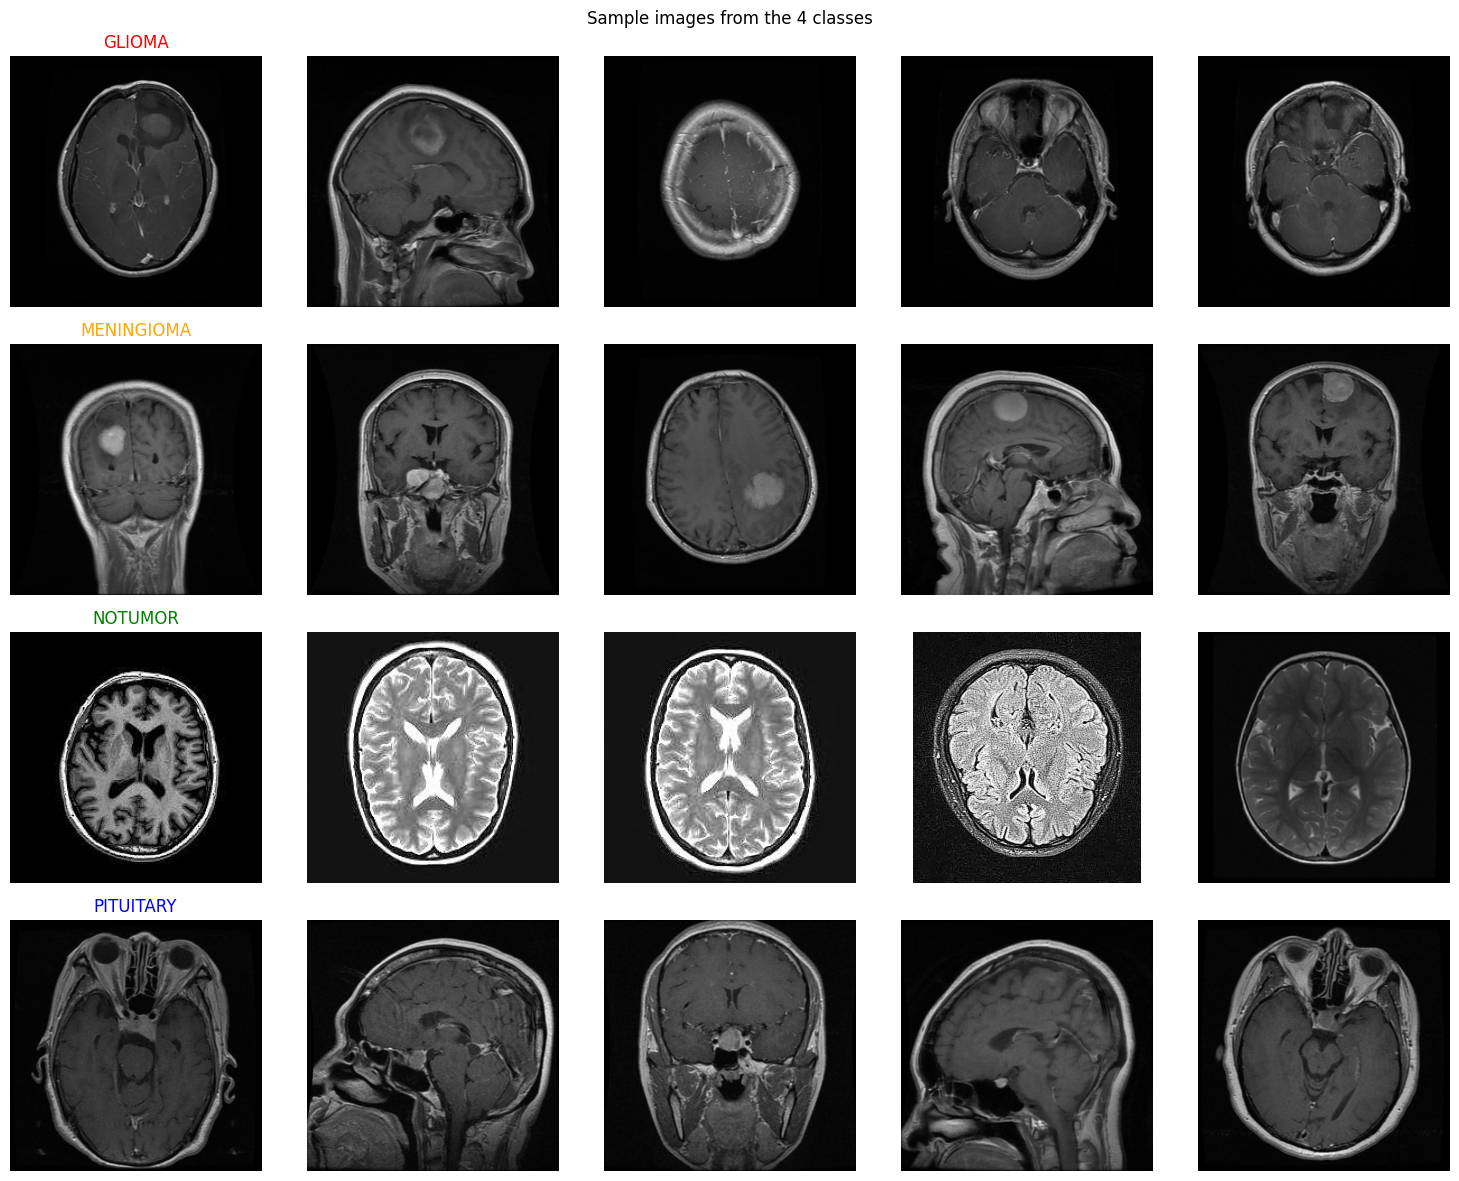

In [5]:
#Exploring the data
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

colors = {'glioma': 'red', 'meningioma': 'orange', 'notumor': 'green', 'pituitary': 'blue'}

for row, cls in enumerate(class_names):
  cls_path = os.path.join(train_dir, cls)
  images = os.listdir(cls_path)
  samples = random.sample(images, min(5, len(images)))

  for col, img_name in enumerate(samples):
    img_path = os.path.join(cls_path, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[row, col].imshow(img)
    axes[row, col].axis('off')
    if col == 0:
      axes[row, col].set_title(cls.upper(), color=colors[cls], fontsize=12)
plt.suptitle('Sample images from the 4 classes')
plt.tight_layout()
plt.show()


Testing set:
  glioma: 400 images
  meningioma: 400 images
  notumor: 400 images
  pituitary: 400 images

Total testing: 1600


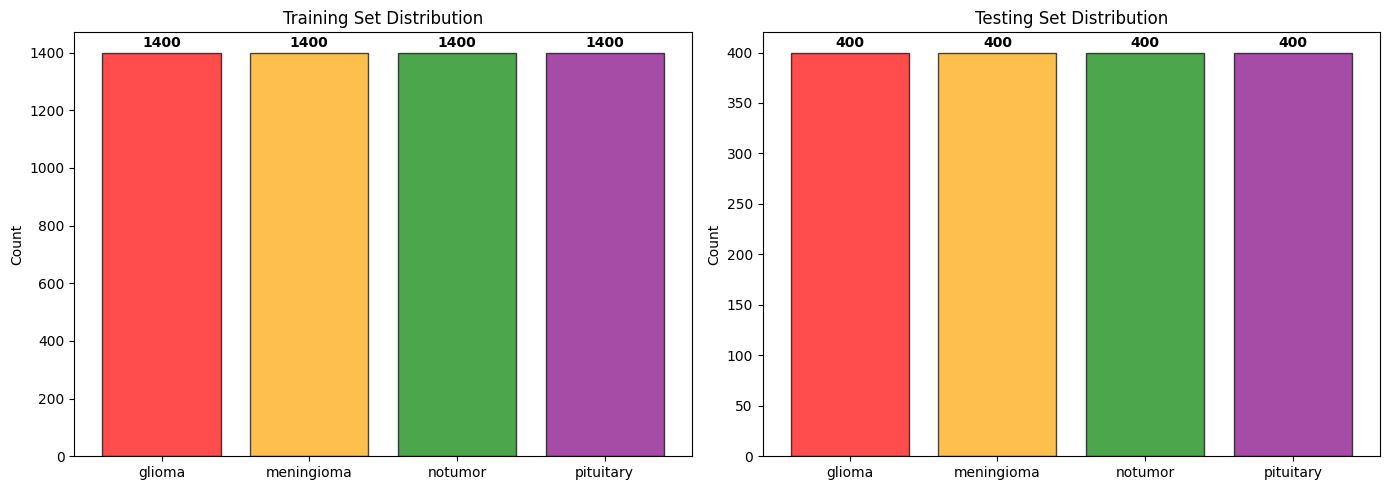

Classes are reasonably balanced!


In [6]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_list = ['red', 'orange', 'green', 'purple']

# Training
axes[0].bar(train_counts.keys(), train_counts.values(), color=colors_list, alpha=0.7, edgecolor='black')
axes[0].set_title('Training Set Distribution')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(train_counts.items()):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Testing
print("\nTesting set:")
test_counts = {}
for cls in class_names:
    path = os.path.join(test_dir, cls)
    if os.path.exists(path):
        count = len(os.listdir(path))
        test_counts[cls] = count
        print(f"  {cls}: {count} images")
print(f"\nTotal testing: {sum(test_counts.values())}")

axes[1].bar(test_counts.keys(), test_counts.values(), color=colors_list, alpha=0.7, edgecolor='black')
axes[1].set_title('Testing Set Distribution')
axes[1].set_ylabel('Count')
for i, (k, v) in enumerate(test_counts.items()):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Classes are reasonably balanced!")

Data Generators

In [40]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest',
    validation_split=0.15
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
)
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
)
print(f"Class indices: {train_generator.class_indices}")

Found 4760 images belonging to 4 classes.
Found 840 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


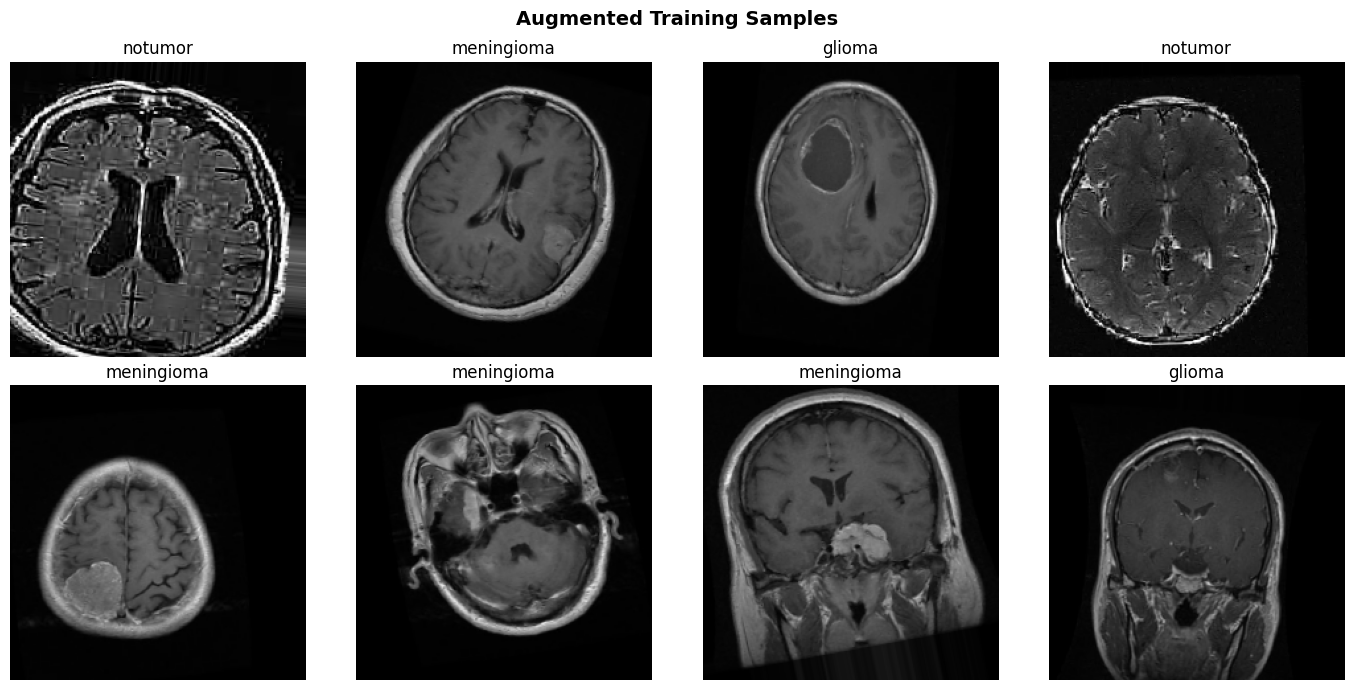

In [19]:
# Visualize augmented samples
x_batch, y_batch = next(train_generator)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

class_labels = list(train_generator.class_indices.keys())

for i in range(8):
    axes[i].imshow(x_batch[i])
    label_idx = np.argmax(y_batch[i])
    axes[i].set_title(f'{class_labels[label_idx]}')
    axes[i].axis('off')

plt.suptitle('Augmented Training Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

CNN Architecture

In [41]:
def deep_cnn(input_shape=(224, 224, 3), num_classes=4):
  model = models.Sequential(name='DeepCNN_BrainTumor')

  #Block 1: 32 filters
  model.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.Conv2D(32, (3, 3), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D(2, 2))

  #Block 2: 64 filters
  model.add(layers.Conv2D(64, (3, 3), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.Conv2D(64, (3, 3), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D(2, 2))

  #Block 3: 128 filters
  model.add(layers.Conv2D(128, (3, 3), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.Conv2D(128, (3, 3), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D(2, 2))

  #Block 4: 256 filters
  model.add(layers.Conv2D(256, (3, 3), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.Conv2D(256, (3, 3), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D(2, 2))

  #BLock 4: 512 layers
  model.add(layers.Conv2D(512, (3, 3), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.Conv2D(512, (3, 3), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.Activation('relu'))
  model.add(layers.MaxPooling2D(2, 2))

  # CLassifier
  model.add(layers.Flatten())
  model.add(layers.Dense(1024, activation='relu'))
  model.add(layers.Dropout(0.5))
  model.add(layers.Dense(512, activation='relu'))
  model.add(layers.Dropout(0.5))
  model.add(layers.Dense(num_classes, activation='softmax'))

  return model

#Build model
model = deep_cnn(num_classes=num_classes)
model.summary()

Model: "DeepCNN_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_33 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_34 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_35 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 28, 28, 256)    │       295,16

 Total params: 30,938,148 (118.02 MB)

 Trainable params: 30,934,180 (118.00 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [42]:
# Count parameters
total_params = model.count_params()
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])

print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Layers: {len(model.layers)}")


Model Statistics:
  Total parameters: 30,938,148
  Trainable parameters: 30,934,180
  Layers: 41


In [43]:
# Compile
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled!")
print("  Optimizer: Adam (lr=0.0001)")
print("  Loss: Categorical Crossentropy")
print("  Metrics: Accuracy")

Model compiled!
  Optimizer: Adam (lr=0.0001)
  Loss: Categorical Crossentropy
  Metrics: Accuracy


In [44]:
#callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = callbacks.ModelCheckpoint(
    'best_brain_tumor_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [25]:
from prompt_toolkit import history
print("Training model...")

history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs=50,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Training model...
Epoch 1/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.4304 - loss: 1.9903
Epoch 1: val_loss improved from None to 1.64112, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 92s 530ms/step - accuracy: 0.5065 - loss: 1.5230 - val_accuracy: 0.2500 - val_loss: 1.6411 - learning_rate: 1.0000e-04
Epoch 2/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.6541 - loss: 0.9475
Epoch 2: val_loss improved from 1.64112 to 1.53805, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 63s 421ms/step - accuracy: 0.6664 - loss: 0.8912 - val_accuracy: 0.2750 - val_loss: 1.5380 - learning_rate: 1.0000e-04
Epoch 3/50
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.7037 - loss: 0.7777
Epoch 3: val_loss did not improve from 1.53805
149/149 ━━━━━━━━━━━━━━━━━━━━ 62s 414ms/step - accuracy: 

Training curves

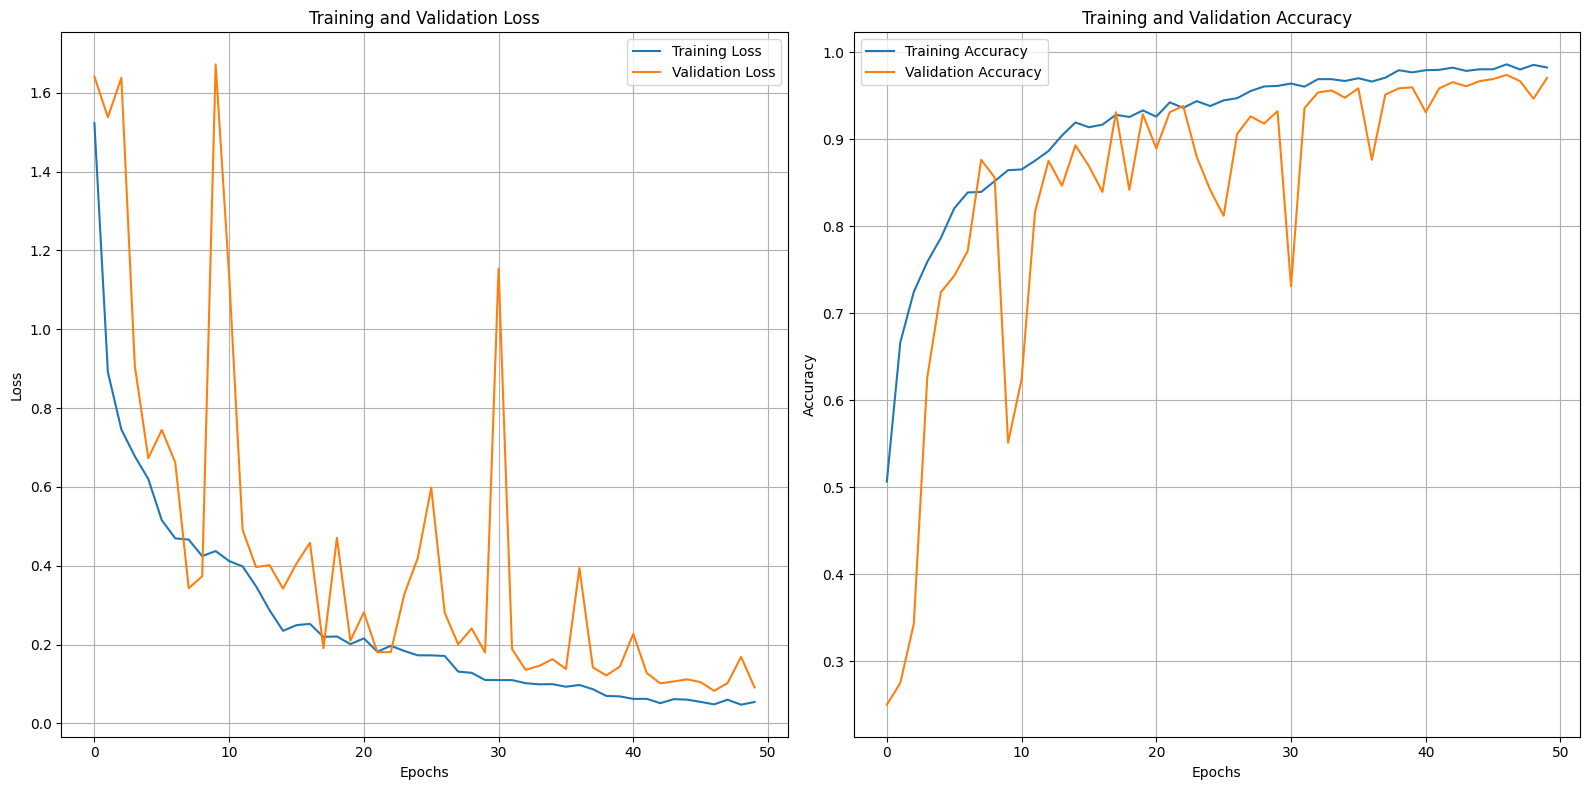

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Evaluating on the test set

In [46]:
best_model = keras.models.load_model('best_brain_tumor_model.keras')
print("Best model loaded!")

Best model loaded!


In [47]:
from numpy.matrixlib import test
test_generator.reset()
test_loss, test_acc = best_model.evaluate(test_generator)

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.9175 - loss: 0.4848


In [48]:
test_generator.reset()
y_pred_prob = best_model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

class_labels = list(test_generator.class_indices.keys())

print(f"Predictions: {len(y_pred)}")
print(f"True labels: {len(y_true)}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step
Predictions: 1600
True labels: 1600


In [49]:
print("\nClassification Report:")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_labels))


Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.96      0.87      0.91       400
     notumor       0.86      1.00      0.92       400
   pituitary       0.90      1.00      0.95       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



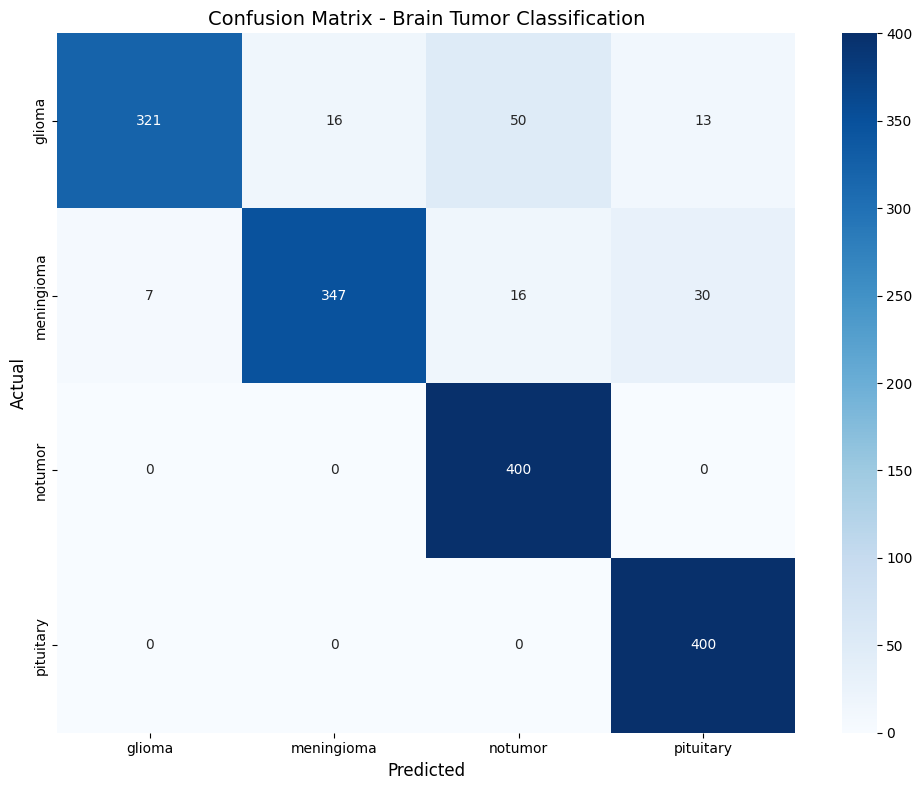


Per-class accuracy:
  glioma: 80.25%
  meningioma: 86.75%
  notumor: 100.00%
  pituitary: 100.00%


In [50]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Brain Tumor Classification', fontsize=14)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, cls in enumerate(class_labels):
    cls_acc = cm[i, i] / cm[i, :].sum()
    print(f"  {cls}: {cls_acc:.2%}")

Visualizing the predictions

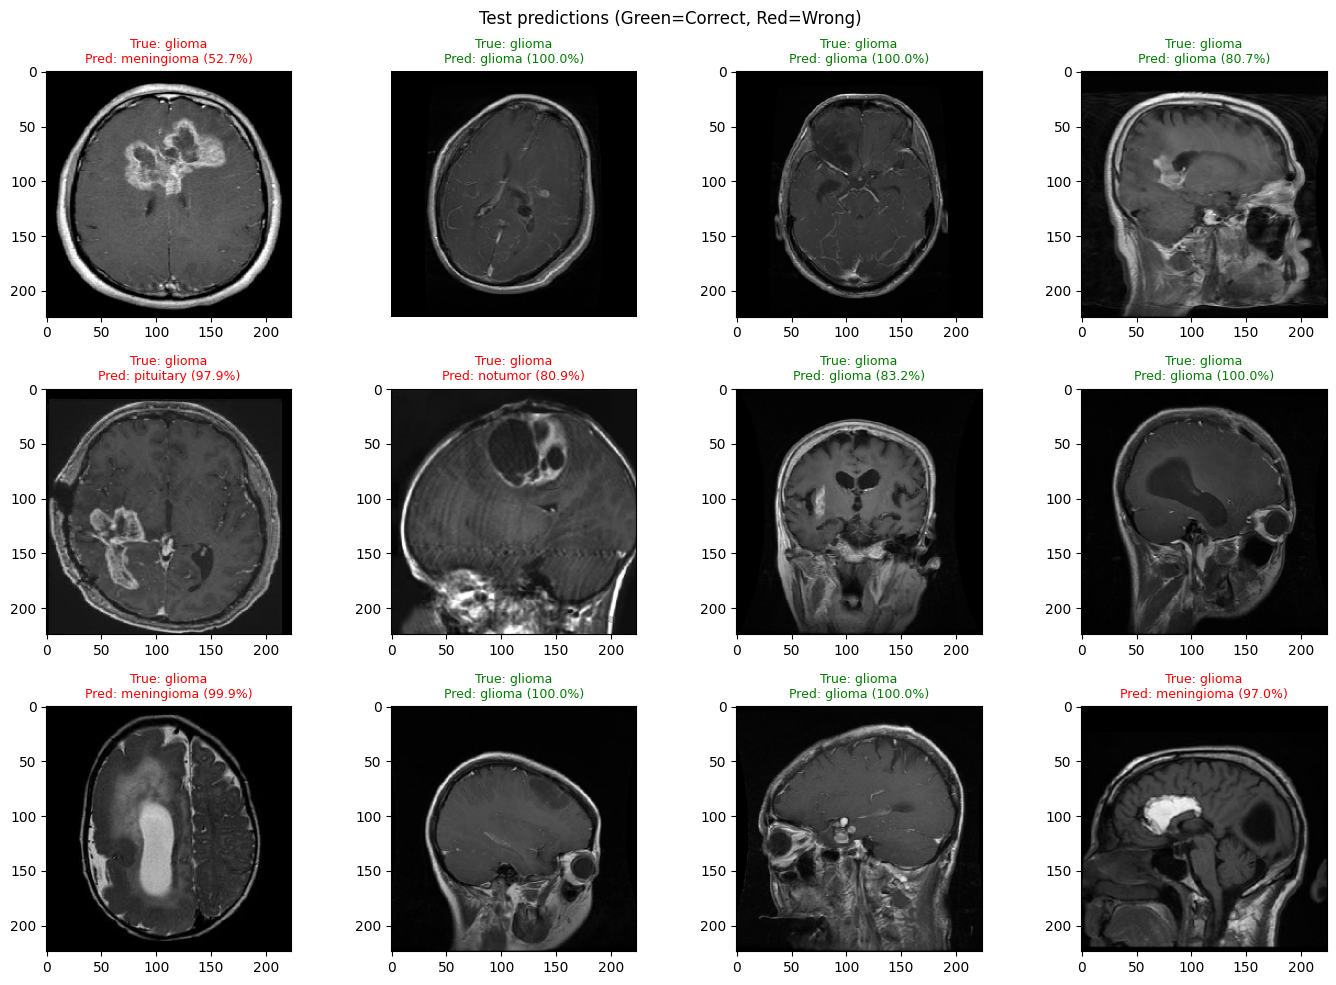

In [51]:
test_generator.reset()
x_batch, y_batch = next(test_generator)
predictions = best_model.predict(x_batch, verbose=0)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i in range(12):
  axes[i].imshow(x_batch[i])

  true_idx = np.argmax(y_batch[i])
  pred_idx = np.argmax(predictions[i])
  conf = predictions[i][pred_idx]

  true_label = class_labels[true_idx]
  pred_label = class_labels[pred_idx]

  color = 'green' if true_idx == pred_idx else 'red'

  axes[i].set_title(f'True: {true_label}\nPred: {pred_label} ({conf:.1%})', color=color, fontsize=9)
  axes[1].axis('off')

plt.suptitle("Test predictions (Green=Correct, Red=Wrong)")
plt.tight_layout()
plt.show()

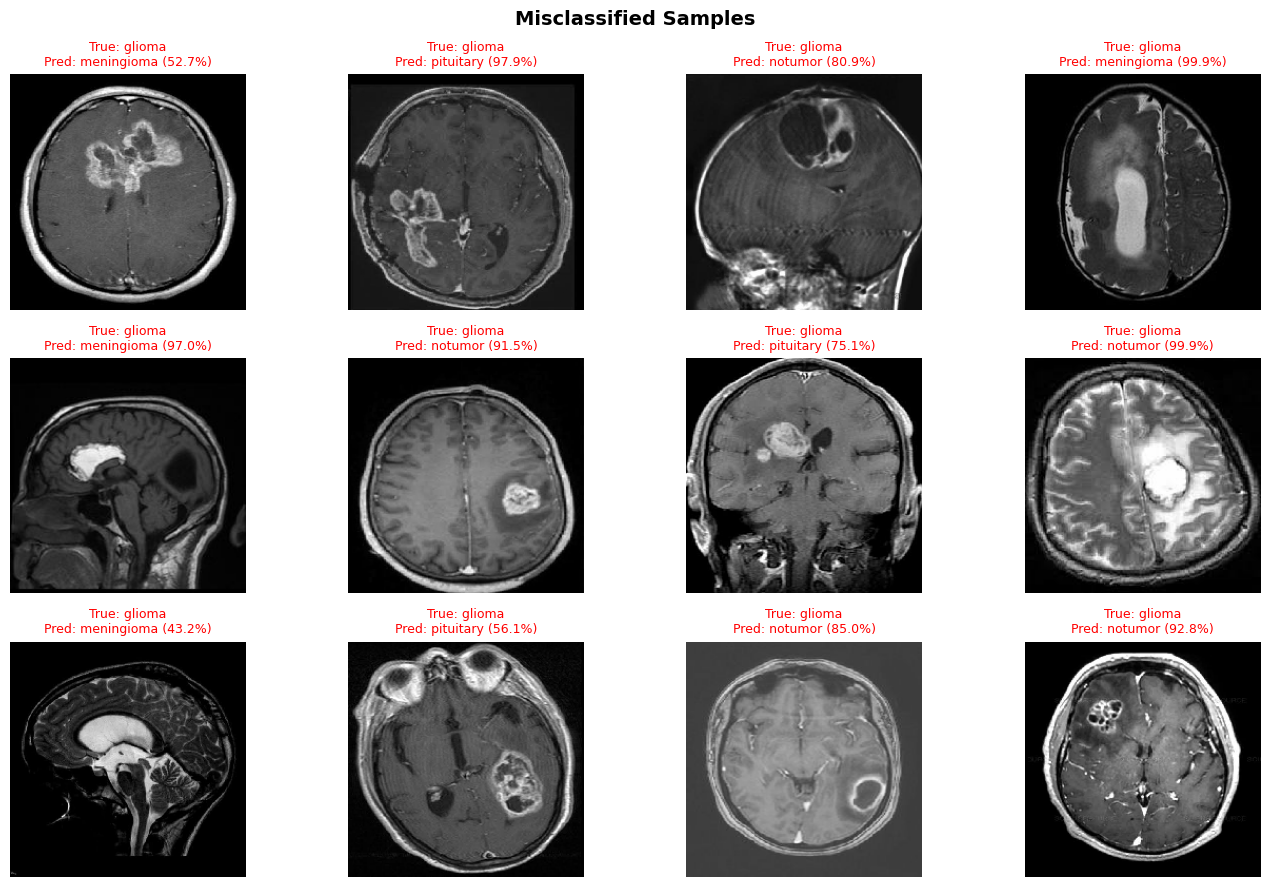

In [52]:
# Show misclassified samples
test_generator.reset()
all_images = []
all_true = []
all_pred = []
all_conf = []

for x_batch, y_batch in test_generator:
    preds = best_model.predict(x_batch, verbose=0)
    for i in range(len(x_batch)):
        true_idx = np.argmax(y_batch[i])
        pred_idx = np.argmax(preds[i])
        if true_idx != pred_idx:
            all_images.append(x_batch[i])
            all_true.append(true_idx)
            all_pred.append(pred_idx)
            all_conf.append(preds[i][pred_idx])
    if len(all_images) >= 12:
        break

if len(all_images) > 0:
    n_show = min(12, len(all_images))
    rows = (n_show + 3) // 4
    fig, axes = plt.subplots(rows, 4, figsize=(14, 3*rows))
    axes = axes.flatten() if rows > 1 else [axes] if rows == 1 else axes

    for i in range(n_show):
        axes[i].imshow(all_images[i])
        axes[i].set_title(f'True: {class_labels[all_true[i]]}\nPred: {class_labels[all_pred[i]]} ({all_conf[i]:.1%})',
                          color='red', fontsize=9)
        axes[i].axis('off')

    for i in range(n_show, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Misclassified Samples', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications found in first batch!")


Grad-Cam Visualization

In [56]:
# Grad-CAM: See what the model "sees"
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

# Find last conv layer
last_conv_layer = None
for layer in reversed(best_model.layers):
    if 'conv' in layer.name:
        last_conv_layer = layer.name
        break

print(f"Last conv layer: {last_conv_layer}")

_ = best_model(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)))

Last conv layer: conv2d_19


In [57]:
# Apply Grad-CAM
def apply_gradcam(img, model, last_conv_layer_name):
    img_array = np.expand_dims(img, axis=0)
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Resize heatmap
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # Superimpose
    superimposed = (heatmap_color * 0.4 + img * 255 * 0.6).astype(np.uint8)

    return heatmap_color, superimposed

AttributeError: The layer DeepCNN_Brain_Tumor has never been called and thus has no defined output.

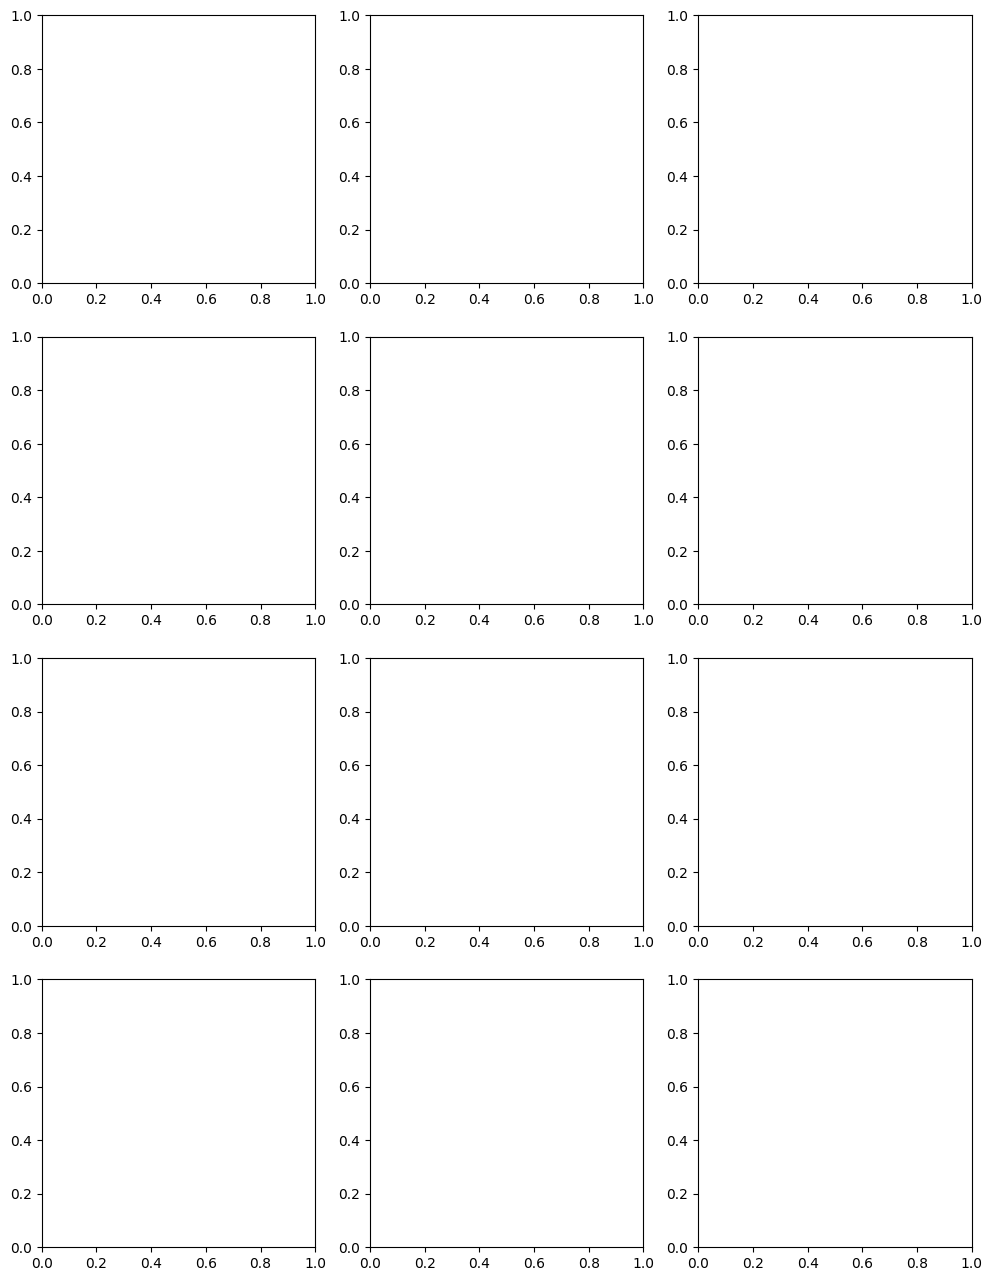

In [58]:
# Visualize Grad-CAM for each class
test_generator.reset()

# Collect one sample per class
class_samples = {i: None for i in range(num_classes)}

for x_batch, y_batch in test_generator:
    for i in range(len(x_batch)):
        cls_idx = np.argmax(y_batch[i])
        if class_samples[cls_idx] is None:
            class_samples[cls_idx] = x_batch[i]
    if all(v is not None for v in class_samples.values()):
        break

# Plot
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for row, (cls_idx, img) in enumerate(class_samples.items()):
    if img is None:
        continue

    heatmap, superimposed = apply_gradcam(img, best_model, last_conv_layer)
    pred = best_model.predict(np.expand_dims(img, 0), verbose=0)[0]
    pred_idx = np.argmax(pred)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Original\n({class_labels[cls_idx]})')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(heatmap)
    axes[row, 1].set_title('Attention Map')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(superimposed)
    axes[row, 2].set_title(f'Overlay\nPred: {class_labels[pred_idx]} ({pred[pred_idx]:.1%})')
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM: Where the Model Looks', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()